# Plant Seedlings Classification using CNN

This notebook implements a Convolutional Neural Network (CNN) to classify **12 species** of plant seedlings using the [Plant Seedlings Dataset](https://www.kaggle.com/c/plant-seedlings-classification).

| | | |
|---|---|---|
| Black-grass | Charlock | Cleavers |
| Common Chickweed | Common wheat | Fat Hen |
| Loose Silky-bent | Maize | Scentless Mayweed |
| Shepherds Purse | Small-flowered Cranesbill | Sugar beet |

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 1. Configuration

Set the path to the dataset. The expected folder structure:

```
data/
├── train/
│   ├── Black-grass/
│   │   ├── 0050f38b3.png
│   │   └── ...
│   ├── Charlock/
│   └── ...  (12 species folders)
├── test/
│   ├── 0021e90e4.png
│   └── ...  (unlabeled images for Kaggle submission)
└── sample_submission.csv
```

**To get the data:** download from [Kaggle](https://www.kaggle.com/c/plant-seedlings-classification/data) and extract into a `data/` directory, or update `DATA_DIR` below.

In [4]:
!unzip data.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/train/Scentless Mayweed/6f9829b56.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._6f9829b56.png  
  inflating: data/train/Scentless Mayweed/ec6e6cfdb.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._ec6e6cfdb.png  
  inflating: data/train/Scentless Mayweed/66f70d982.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._66f70d982.png  
  inflating: data/train/Scentless Mayweed/2bdd11146.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._2bdd11146.png  
  inflating: data/train/Scentless Mayweed/d30507567.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._d30507567.png  
  inflating: data/train/Scentless Mayweed/22e662983.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._22e662983.png  
  inflating: data/train/Scentless Mayweed/0d58d5433.png  
  inflating: __MACOSX/data/train/Scentless Mayweed/._0d58d5433.png  
  inflating: data/train/Scentless Mayweed/6334e8b6d.png  
  

In [5]:
DATA_DIR = "data"
IMG_SIZE = 128

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

assert os.path.isdir(TRAIN_DIR), f"Training directory not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Test directory not found: {TEST_DIR}"
print(f"Data directory: {os.path.abspath(DATA_DIR)}")

Data directory: /content/data


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Data

Load training images from the folder structure. Each subfolder name in `train/` is the species label.

In [7]:
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith(".")
])
NUM_CLASSES = len(class_names)

images = []
labels = []

for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    file_list = [f for f in os.listdir(class_dir) if f.lower().endswith(".png")]
    for img_name in file_list:
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(class_name)
    print(f"  {class_name}: {len(file_list)} images")

images = np.array(images)
labels = np.array(labels)
print(f"\nTotal: {len(images)} training images across {NUM_CLASSES} classes")
print(f"Image shape: {images[0].shape}")

  Black-grass: 263 images
  Charlock: 390 images
  Cleavers: 287 images
  Common Chickweed: 611 images
  Common wheat: 221 images
  Fat Hen: 475 images
  Loose Silky-bent: 654 images
  Maize: 221 images
  Scentless Mayweed: 516 images
  Shepherds Purse: 231 images
  Small-flowered Cranesbill: 496 images
  Sugar beet: 385 images

Total: 4750 training images across 12 classes
Image shape: (128, 128, 3)


In [8]:
label_series = pd.Series(labels, name="Label")
print(label_series.value_counts().to_string())
print(f"\nTotal images: {len(labels)}")

Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Maize                        221
Common wheat                 221

Total images: 4750


## 3. Explore Data

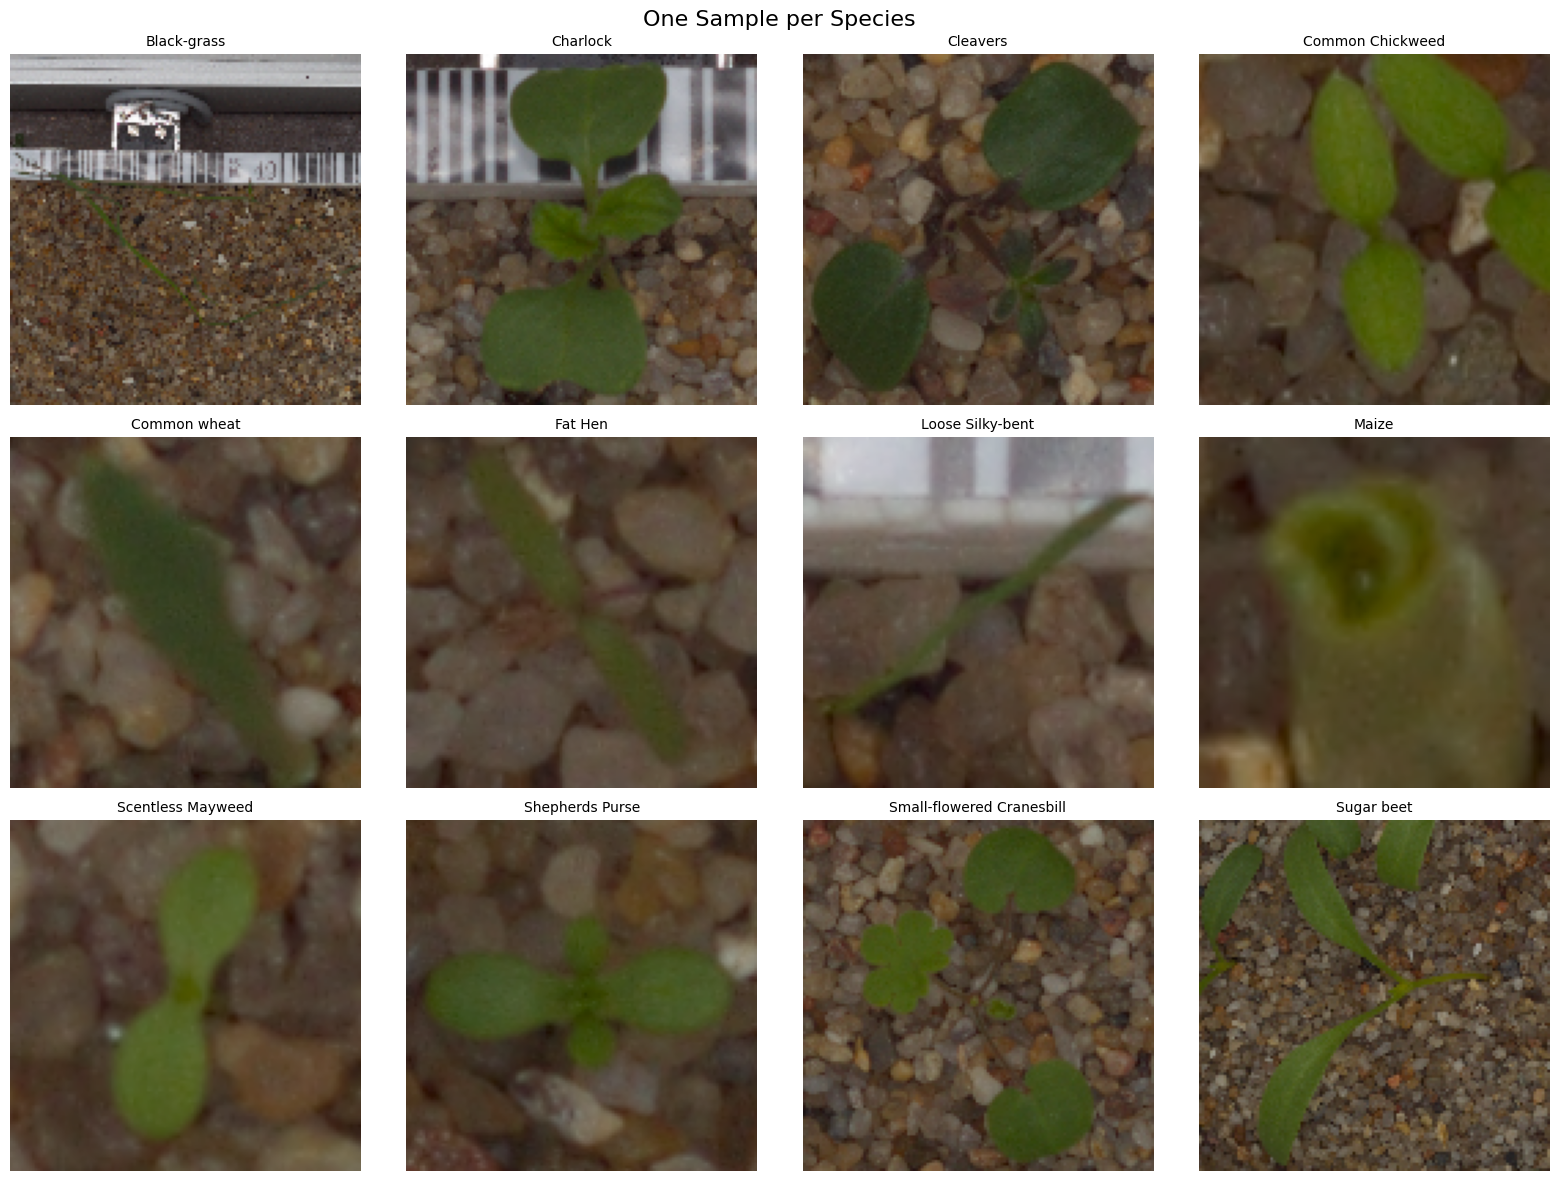

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("One Sample per Species", fontsize=16)

for ax, class_name in zip(axes.flat, class_names):
    idx = np.where(labels == class_name)[0][0]
    ax.imshow(images[idx])
    ax.set_title(class_name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

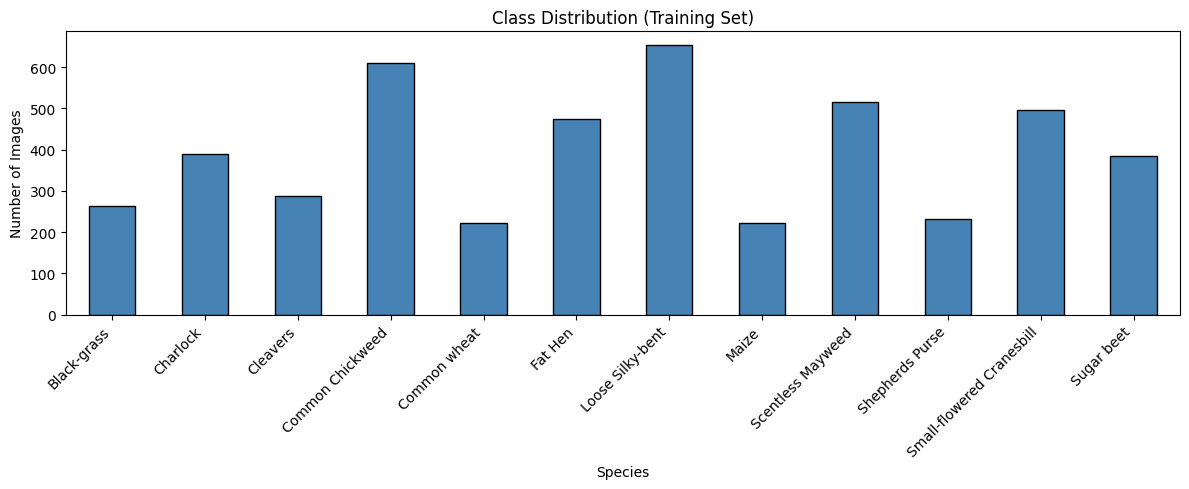

In [10]:
plt.figure(figsize=(12, 5))
pd.Series(labels).value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Class Distribution (Training Set)")
plt.xlabel("Species")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Preprocessing

Apply Gaussian blur to reduce noise, then normalize pixel values to \[0, 1\].

In [11]:
def preprocess_images(imgs):
    """Apply Gaussian blur and normalize to [0, 1]."""
    processed = np.empty_like(imgs, dtype=np.float32)
    for i, img in enumerate(imgs):
        processed[i] = cv2.GaussianBlur(img, (5, 5), 0)
    return processed / 255.0

X_all = preprocess_images(images)
print(f"Preprocessed shape: {X_all.shape}, dtype: {X_all.dtype}")

Preprocessed shape: (4750, 128, 128, 3), dtype: float32


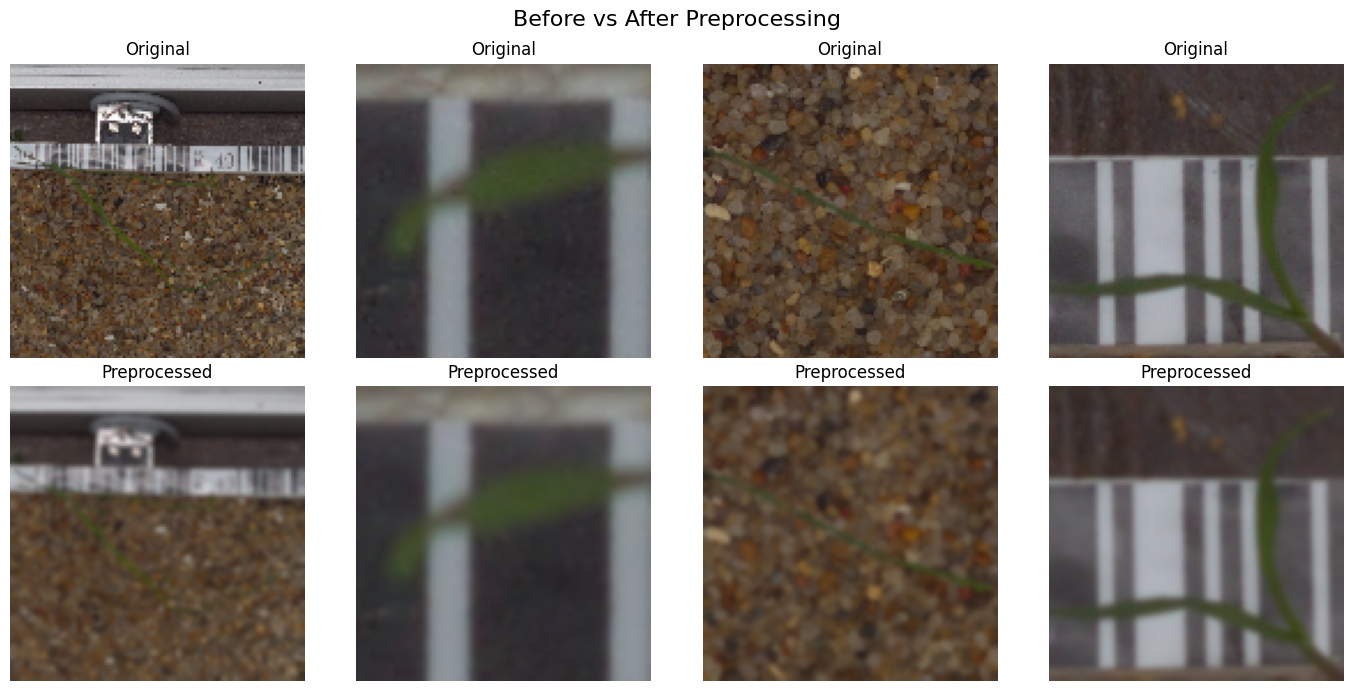

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Before vs After Preprocessing", fontsize=16)
for i in range(4):
    axes[0, i].imshow(images[i])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_all[i])
    axes[1, i].set_title("Preprocessed")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 5. Prepare Labels & Split Data

Encode labels as one-hot vectors using `LabelBinarizer`, then split into **train (70%)**, **validation (15%)**, and **test (15%)** sets.

> The Kaggle test set has no labels, so we create our own labeled test split for evaluation.

In [13]:
enc = LabelBinarizer()
y_all = enc.fit_transform(labels)
CLASS_NAMES = enc.classes_

print(f"Classes: {list(CLASS_NAMES)}")
print(f"One-hot shape: {y_all.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTraining set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

Classes: [np.str_('Black-grass'), np.str_('Charlock'), np.str_('Cleavers'), np.str_('Common Chickweed'), np.str_('Common wheat'), np.str_('Fat Hen'), np.str_('Loose Silky-bent'), np.str_('Maize'), np.str_('Scentless Mayweed'), np.str_('Shepherds Purse'), np.str_('Small-flowered Cranesbill'), np.str_('Sugar beet')]
One-hot shape: (4750, 12)

Training set:   (3325, 128, 128, 3)
Validation set: (712, 128, 128, 3)
Test set:       (713, 128, 128, 3)


## 6. Data Augmentation

Apply real-time augmentation during training to improve generalization.

In [14]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    fill_mode="nearest",
)
datagen.fit(X_train)

## 7. Build CNN Model

A Sequential CNN with four convolutional blocks, batch normalization, and progressive dropout.

In [15]:
model = models.Sequential([
    layers.Conv2D(32, (5, 5), padding="same", activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (5, 5), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),

    layers.GlobalMaxPooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,172 (578.80 KB)

 Trainable params: 147,724 (577.05 KB)

 Non-trainable params: 448 (1.75 KB)

## 8. Train Model

In [16]:
BATCH_SIZE = 32
EPOCHS = 30

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 42s 264ms/step - accuracy: 0.1738 - loss: 3.4935 - val_accuracy: 0.0997 - val_loss: 2.4818 - learning_rate: 0.0010
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.3359 - loss: 1.9262 - val_accuracy: 0.1404 - val_loss: 2.7849 - learning_rate: 0.0010
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.4099 - loss: 1.6858 - val_accuracy: 0.1587 - val_loss: 2.9049 - learning_rate: 0.0010
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4483 - loss: 1.5870
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 152ms/step - accuracy: 0.4526 - loss: 1.5685 - val_accuracy: 0.1517 - val_loss: 2.9423 - learning_rate: 0.0010
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.5122 - loss: 1.3895 - val_accuracy: 0.2247 - val_loss: 2.2848 - learning_rate: 5.0000e-04
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0

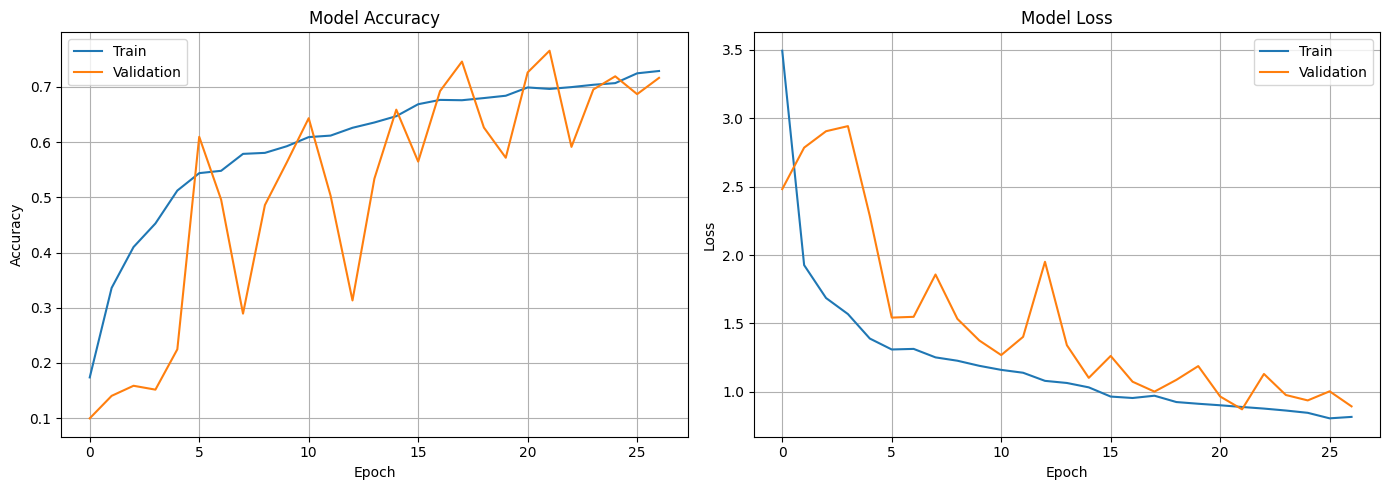

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 9. Evaluate Model

In [18]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASS_NAMES))

Test Loss:     0.9116
Test Accuracy: 0.7616
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

Classification Report:
                           precision    recall  f1-score   support

              Black-grass       0.50      0.05      0.09        39
                 Charlock       0.98      0.69      0.81        58
                 Cleavers       0.80      0.74      0.77        43
         Common Chickweed       0.77      0.99      0.87        92
             Common wheat       0.84      0.79      0.81        33
                  Fat Hen       0.69      0.89      0.78        72
         Loose Silky-bent       0.66      0.95      0.78        98
                    Maize       0.95      0.61      0.74        33
        Scentless Mayweed       0.76      0.72      0.74        78
          Shepherds Purse       0.75      0.26      0.39        34
Small-flowered Cranesbill       0.85      0.85      0.85        75
               Sugar beet       0.72      0.79      0.75        58

                 ac

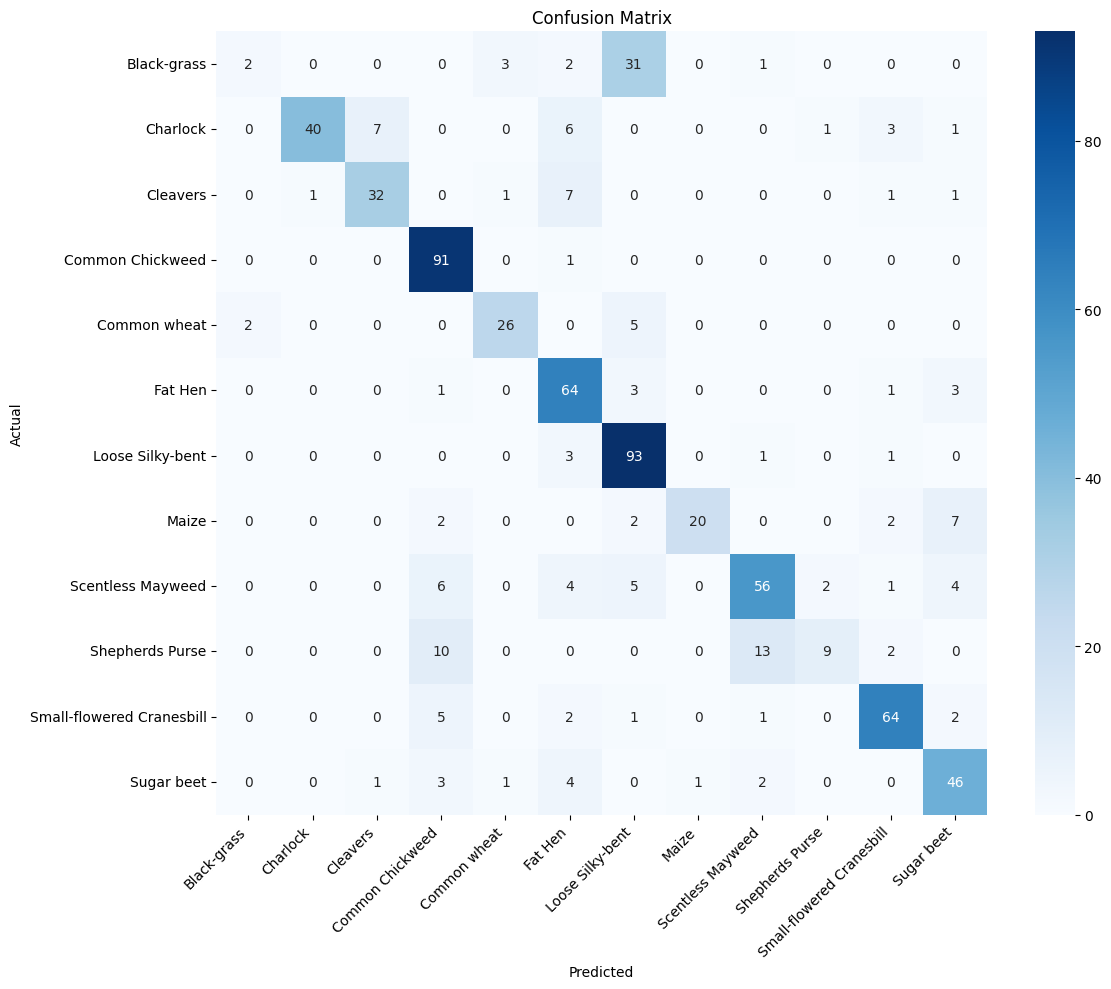

In [19]:
conf_mat = confusion_matrix(y_true_classes, y_pred_classes)
df_cm = pd.DataFrame(conf_mat, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(12, 10))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

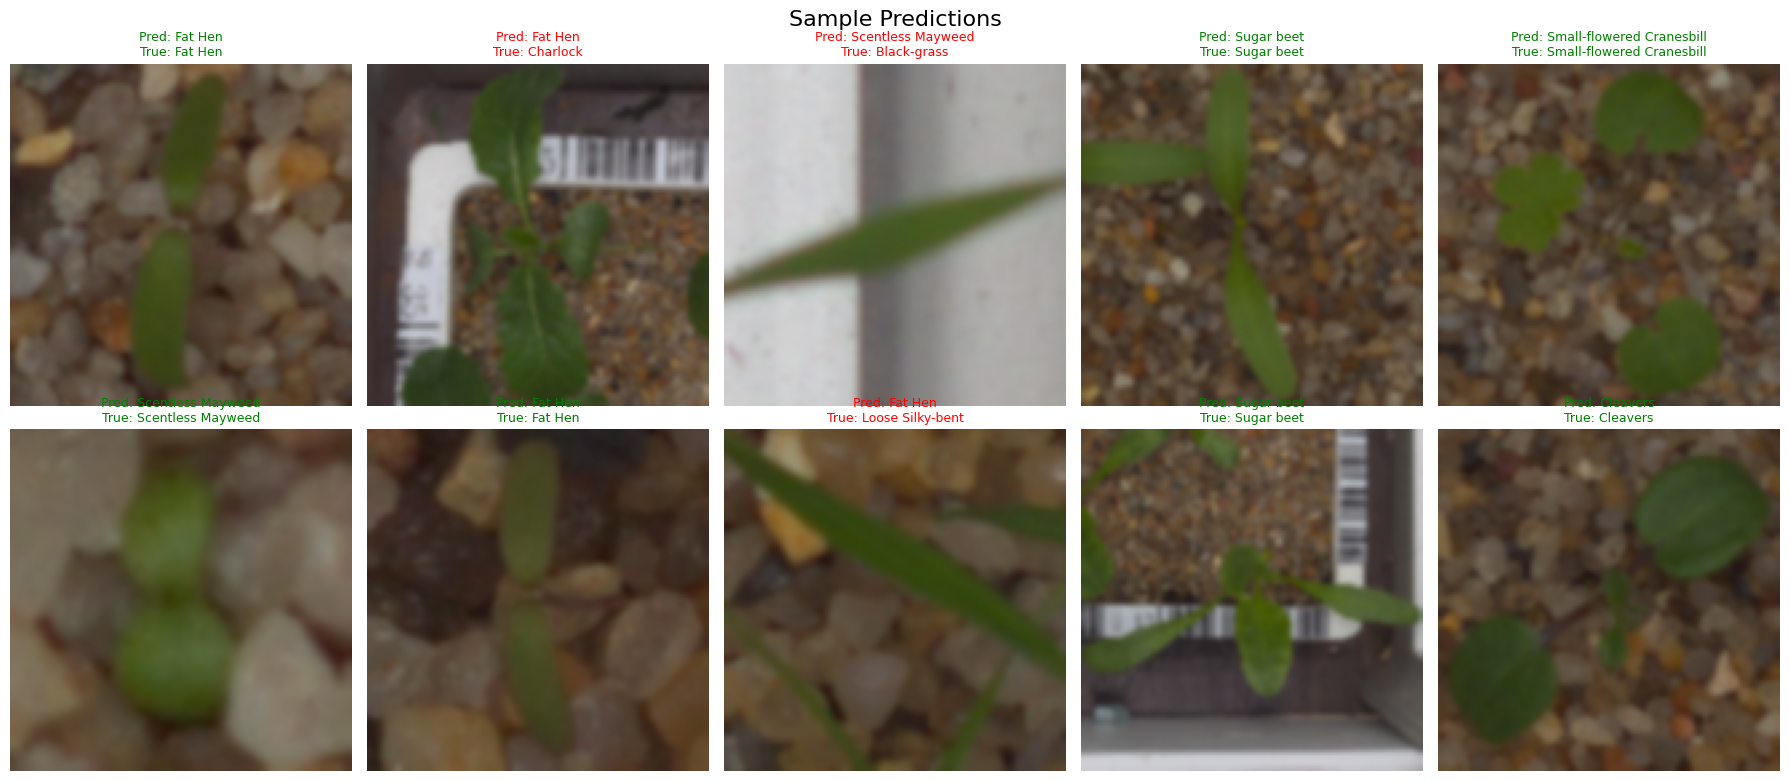

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample Predictions", fontsize=16)

indices = np.random.choice(len(X_test), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_test[idx])
    pred_label = CLASS_NAMES[y_pred_classes[idx]]
    true_label = CLASS_NAMES[y_true_classes[idx]]
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=9, color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Save Model

Save the trained model and class names for use in the Gradio demo app.

In [21]:
os.makedirs("model", exist_ok=True)
model.save("model/plant_seedling_model.keras")
np.save("model/class_names.npy", CLASS_NAMES)
print("Model and class names saved to model/ directory")

Model and class names saved to model/ directory


## 11. Kaggle Submission (Optional)

Generate predictions on the unlabeled Kaggle test set and save as a submission CSV.

In [22]:
test_filenames = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(".png")
])

test_images = []
for img_name in test_filenames:
    img_path = os.path.join(TEST_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    test_images.append(img)
test_images = np.array(test_images)
print(f"Loaded {len(test_images)} Kaggle test images")

test_processed = preprocess_images(test_images)
test_pred = model.predict(test_processed)
test_pred_labels = [CLASS_NAMES[i] for i in np.argmax(test_pred, axis=1)]

submission = pd.DataFrame({"file": test_filenames, "species": test_pred_labels})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved to submission.csv ({len(submission)} predictions)")
submission.head(10)

Loaded 794 Kaggle test images
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
Submission saved to submission.csv (794 predictions)


,file,species
0,0021e90e4.png,Small-flowered Cranesbill
1,003d61042.png,Fat Hen
2,007b3da8b.png,Sugar beet
3,0086a6340.png,Common Chickweed
4,00c47e980.png,Sugar beet
5,00d090cde.png,Fat Hen
6,00ef713a8.png,Common Chickweed
7,01291174f.png,Fat Hen
8,026716f9b.png,Loose Silky-bent
9,02cfeb38d.png,Loose Silky-bent
